In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import dataloader_model_latents,UMAP_train
from utils.plotting_utils import umap_2Dplot


In [3]:
data_str = 'vin_pax_zyx_act_wholecell'
pro_str = 'pax_wholecell_norm_correctloader'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim = 8
BN_flag = True
dropout_flag = True
epochs = int(1000)
lr = 1e-4
loss_norm_flag = 1

dir_list = [
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_0948',
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_1005',    
]


In [4]:
# Define preprocessing transforms here.
# Normalization is usually included as part of the transform pipeline,
# which is passed into the Dataset during initialization.

# this setting is with no normalization
v_min = 0
v_max = 1

transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: x*240.0/255.0
])

# load and combine datasets
datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)



/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/dataset.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


Epoch 20/1000, Train Loss: 0.1680, Val Loss: 0.1582
Epoch 40/1000, Train Loss: 0.1579, Val Loss: 0.1513
Epoch 60/1000, Train Loss: 0.1538, Val Loss: 0.1493
Epoch 80/1000, Train Loss: 0.1513, Val Loss: 0.1477
Epoch 100/1000, Train Loss: 0.1489, Val Loss: 0.1475
torch.Size([128, 1, 32, 32])
Input stats — min: 0.0000, max: 0.9486, mean: 0.1885, std: 0.1858
Reconstruction stats — min: 0.0020, max: 0.9061, mean: 0.1894, std: 0.1571
Epoch 120/1000, Train Loss: 0.1471, Val Loss: 0.1487
Epoch 140/1000, Train Loss: 0.1454, Val Loss: 0.1481
Epoch 160/1000, Train Loss: 0.1444, Val Loss: 0.1488
Epoch 180/1000, Train Loss: 0.1426, Val Loss: 0.1489
Epoch 200/1000, Train Loss: 0.1418, Val Loss: 0.1494
torch.Size([128, 1, 32, 32])
Input stats — min: 0.0000, max: 0.9486, mean: 0.1885, std: 0.1858
Reconstruction stats — min: 0.0016, max: 0.9238, mean: 0.1873, std: 0.1550
Epoch 220/1000, Train Loss: 0.1406, Val Loss: 0.1506
Epoch 240/1000, Train Loss: 0.1397, Val Loss: 0.1509
Epoch 260/1000, Train Loss: 

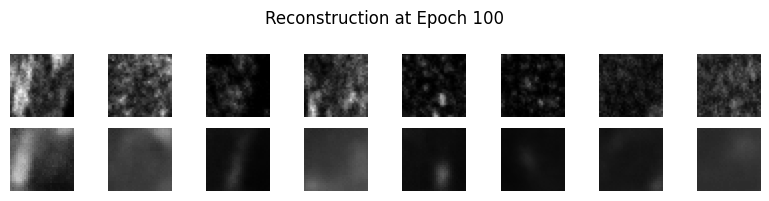

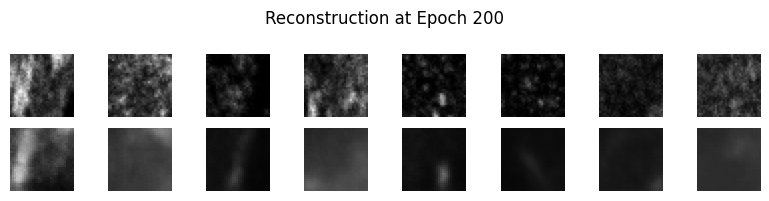

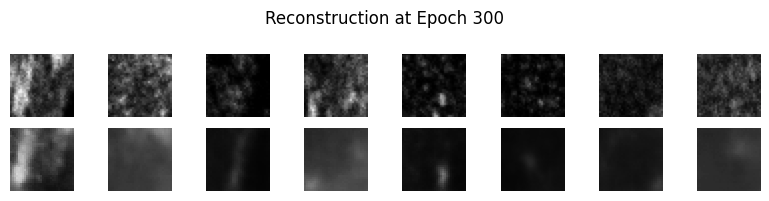

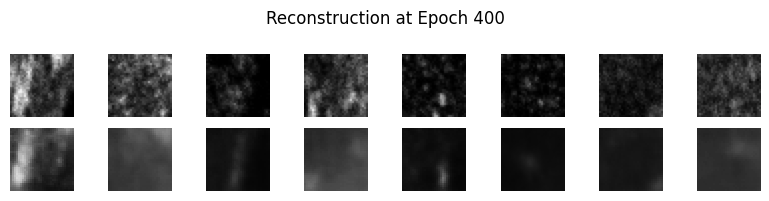

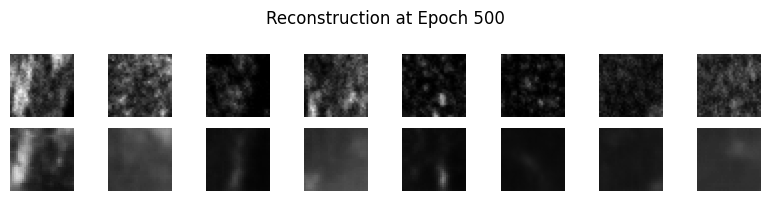

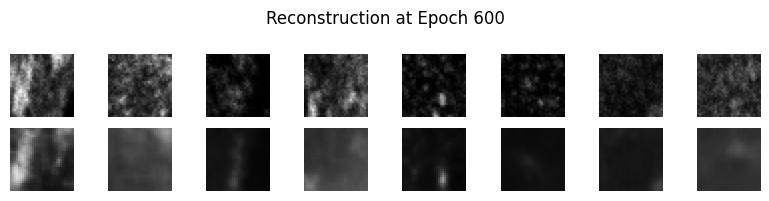

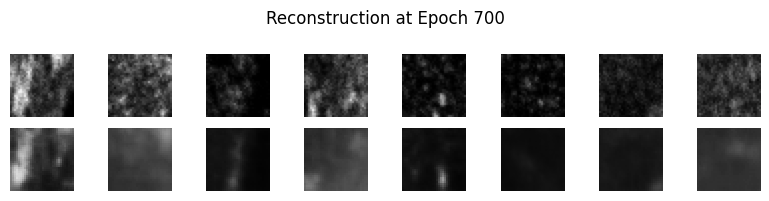

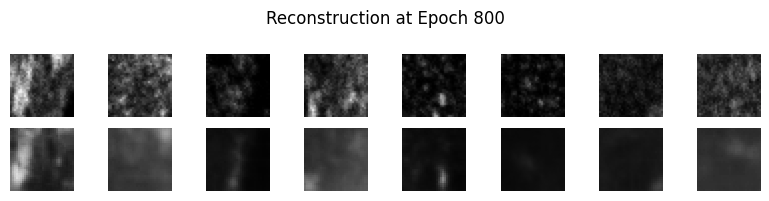

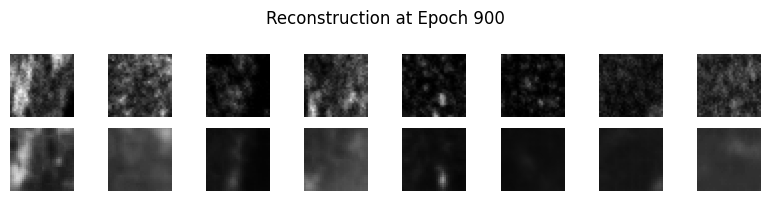

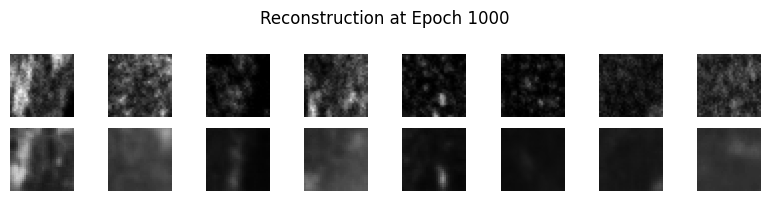

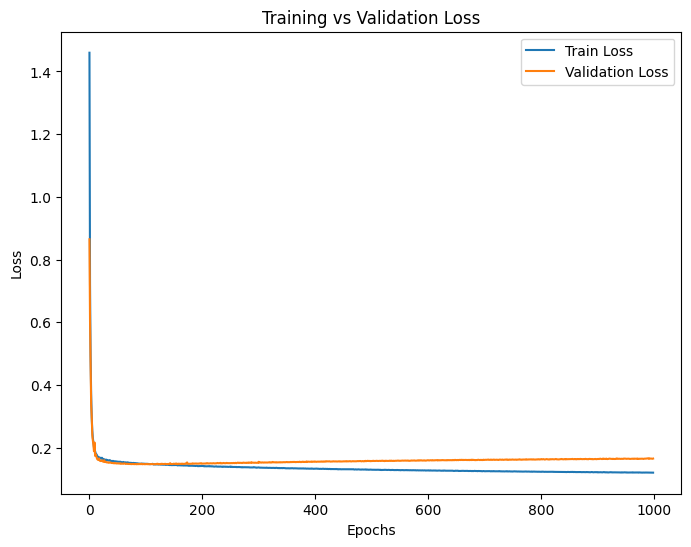

In [5]:
now = datetime.now()

time_str = now.strftime("%Y%m%d_%H%M")

result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
os.makedirs(result_dir, exist_ok=True)

# Define AE
ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

# Train AE
ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)



In [6]:
# obtain the latent features
latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

if isinstance(group_id, torch.Tensor):
    group_id = group_id.cpu().numpy()
elif isinstance(group_id, list):
    group_id = torch.cat(group_id).cpu().numpy()
    
print(latents.shape)
print(images.shape)


(23656, 8)
torch.Size([23656, 1, 32, 32])


/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


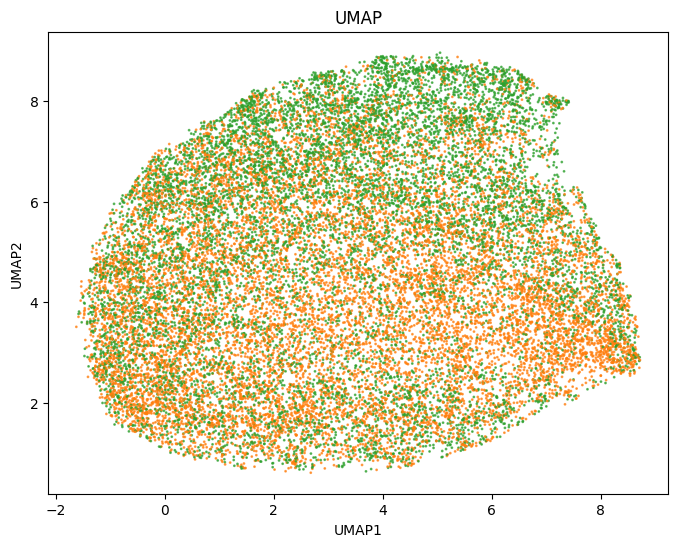

In [7]:
umap_model_name = "vin_pax_zyx_act_wholecell_240255_umap"

latents_2d = UMAP_train(latents, result_dir,umap_model_name)

fig = umap_2Dplot(latents_2d, 0,1,group_id)
    